<div align="center">
<p style="text-align:center;color:#06344ef6;font-size:25px;font-family:bodoni MT">Ecole Nationale de la Statistique et de l'Analyse Economique Pierre NDIAYE (ENSAE) </br> 
</p>
<center><img src="https://ensai.fr/wp-content/uploads/2019/07/ENSAE-Dakar-logo.png"  width="100"></center>
<h1 style="font-family:'Bodoni MT', serif; color:#06344e; margin-top: 25px;">CHURN SCORING — FORTUNEO BANK</h1>
<h3 style="font-family:'Times New Roman', serif; color:#444; font-weight:normal;">Notebook 02 — Traitement et feature engineering</h3>

<hr style="border: 1.5px solid #06344e; width:80%; margin:20px auto;"/>

<table style="width:80%; margin:auto; font-family:'Times New Roman', serif; border-collapse:collapse;">
    <tr>
        <td style="width:55%; vertical-align:top; padding:10px 20px 10px 0; border-right:2px solid #06344e; text-align:left;">
            <p style="font-family:'Bodoni MT', serif; font-weight:bold; font-size:18px; color:#06344e; margin-bottom:10px;">Réalisé par :</p>
            <ul style="font-size:15px; line-height:2; padding-left:20px; margin:0;">
                <li>Paul BALAFAI</li>
                <li>Ameth FAYE</li>
                <li>Sarah-Laure FOGWOUNG DJOUFACK</li>
                <li>Prosper LAWA FOUMSOU</li>
            </ul>
            <p style="font-style:italic; color:#06344e; font-size:13px; margin-top:8px;">
                Elèves Ingénieurs Statisticiens Économistes
            </p>
        </td>
        <td style="width:45%; vertical-align:top; padding:10px 0 10px 20px; text-align:left;">
            <p style="font-family:'Bodoni MT', serif; font-weight:bold; font-size:18px; color:#06344e; margin-bottom:10px;">Sous la supervision de :</p>
            <p style="font-size:15px; margin:4px 0;">Madame Mously DIAW</p>
            <p style="font-style:italic; color:#06344e; font-size:13px; margin-top:8px;">
                Machine Learning Engineer<br>Formatrice IA
            </p>
        </td>
    </tr>
</table>

<hr style="border: 1.5px solid #06344e; width:80%; margin:20px auto;"/>

</div>

### Identité du document
- **Objectif** : nettoyer les données brutes (outliers, colonnes identifiantes, contraintes métier) puis construire et encoder les variables les plus discriminantes pour prédire le churn.
- **Structure** : **Prétraitement** (Sections 3–5) puis **Feature Engineering** (Sections 6–9).
- **Livrables** : données prétraitées, pipeline d'encodage + ratios, contrôle du dataset final.
- **Variables finales (prédicteurs)** : **15 variables** dont 8 numériques conservées + 3 encodées one-hot (Geography_Germany, Geography_Spain, Gender_Male) + 4 ratios construits (Balance_per_Product, Tenure_Age_Ratio, Balance_Age_Ratio, Salary_Age).

# Table des matières
- [Section 0 : Importation des packages](#section-0)
- [Section 1 : Configuration et initialisation](#section-1)
- [Section 2 : Chargement des données](#section-2)
- [Section 3 : Suppression des colonnes identifiantes](#section-3)
- [Section 4 : Traitement des outliers](#section-4)
- [Section 5 : Vérification des contraintes métier](#section-5)
- [Section 6 : Variables de base et justification](#section-6)
- [Section 7 : Variables construites et justification](#section-7)
- [Section 8 : Application du pipeline](#section-8)
- [Section 9 : Contrôle des nouvelles variables](#section-9)
- [Section 10 : Synthèse](#section-10)

<a id="section-0"></a>
# Section 0 : Importation des packages


In [1]:
import importlib
import logging
import warnings
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

CURRENT_DIR = Path.cwd().resolve()
if (CURRENT_DIR / "src").exists():
    PROJECT_ROOT = CURRENT_DIR
elif (CURRENT_DIR.parent / "src").exists():
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    raise FileNotFoundError("Impossible de localiser la racine du projet depuis le notebook.")

SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import feature_engineering.feature_engineering as _fe_mod
import feature_engineering.build_features as _bf_mod
importlib.reload(_fe_mod)
importlib.reload(_bf_mod)

from data.load_data import load_data_raw
from data.clean_data import run_cleaning_pipeline
from feature_engineering.build_features import run_feature_engineering_pipeline
from utils.config_loader import load_config, create_directories
from utils.eda_logger import setup_eda_logger
from omegaconf import OmegaConf


<a id="section-1"></a>
# Section 1 : Configuration et initialisation


In [2]:
cfg = load_config()
setup_eda_logger(cfg)
logger = logging.getLogger(__name__)
create_directories(cfg)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

NOTEBOOK_REPORT_DIR = PROJECT_ROOT / "reports" / "02_notebook"
IMAGES_DIR = NOTEBOOK_REPORT_DIR / "images"
NOTEBOOK_REPORT_DIR.mkdir(parents=True, exist_ok=True)
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

OUTLIER_METHOD     = "iqr"   
IQR_FACTOR         = 3.0
ZSCORE_THRESH      = 3.5
NUM_CONT_COLS      = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary']
COULEUR_PRINCIPALE = '#06344e'
COULEUR_CHURN      = '#e07b39'

cfg.feature_engineering

2026-05-09 10:30:16,034 - utils.config_loader - INFO - Répertoire prêt : C:\Users\DELL\Desktop\ise2\Semestre2\Statistiques\Machine Learning 2\Projet_ML2\Projet_ML2_G8\data\raw
2026-05-09 10:30:16,037 - utils.config_loader - INFO - Répertoire prêt : C:\Users\DELL\Desktop\ise2\Semestre2\Statistiques\Machine Learning 2\Projet_ML2\Projet_ML2_G8\data\interim
2026-05-09 10:30:16,039 - utils.config_loader - INFO - Répertoire prêt : C:\Users\DELL\Desktop\ise2\Semestre2\Statistiques\Machine Learning 2\Projet_ML2\Projet_ML2_G8\data\processed
2026-05-09 10:30:16,039 - utils.config_loader - INFO - Répertoire prêt : C:\Users\DELL\Desktop\ise2\Semestre2\Statistiques\Machine Learning 2\Projet_ML2\Projet_ML2_G8\figures
2026-05-09 10:30:16,039 - utils.config_loader - INFO - Répertoire prêt : C:\Users\DELL\Desktop\ise2\Semestre2\Statistiques\Machine Learning 2\Projet_ML2\Projet_ML2_G8\reports


{'output_dir': 'data/processed', 'filename': 'data_final.csv', 'params': {'year_ref': 2026, 'eps': 1e-06}, 'selection': {'drop_leaky': True, 'keep_raw_energy': True}, 'created_features': ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain', 'Gender_Male', 'Balance_per_Product', 'Tenure_Age_Ratio', 'Balance_Age_Ratio', 'Salary_Age']}

<a id="section-2"></a>
# Section 2 : Chargement des données

In [3]:
df_raw = load_data_raw(cfg)
df = df_raw.copy()
print(f"Shape avant feature engineering : {df.shape}")
df.head()

2026-05-09 10:30:16,553 - data.load_data - INFO - DataFrame chargé : 165034 lignes, 14 colonnes
2026-05-09 10:30:16,715 - data.load_data - INFO -  Bank_churn.csv : Identique à la version précédente.


Shape avant feature engineering : (165034, 14)


,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15674932,Okwudilichukwu,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0
1,1,15749177,Okwudiliolisa,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0
2,2,15694510,Hsueh,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0
3,3,15741417,Kao,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0
4,4,15766172,Chiemenam,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0


# **Processing**

<a id="section-3"></a>
## Section 3 : Suppression des colonnes identifiantes

Les colonnes `id`, `CustomerId` et `Surname` n'apportent aucune information prédictive.
Elles sont supprimées avant la construction du pipeline.

In [4]:
ID_COLS      = ['id', 'CustomerId', 'Surname']
cols_present = [c for c in ID_COLS if c in df.columns]

df = df.drop(columns=cols_present)
logger.info("Colonnes identifiantes supprimées : %s", cols_present)
print(f"Colonnes supprimées   : {cols_present}")
print(f"Shape après suppression : {df.shape}")
df.head(3)

2026-05-09 10:30:16,789 - __main__ - INFO - Colonnes identifiantes supprimées : ['id', 'CustomerId', 'Surname']


Colonnes supprimées   : ['id', 'CustomerId', 'Surname']
Shape après suppression : (165034, 11)


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,668,France,Male,33.0,3,0.0,2,1.0,0.0,181449.97,0
1,627,France,Male,33.0,1,0.0,2,1.0,1.0,49503.50,0
2,678,France,Male,40.0,10,0.0,2,1.0,0.0,184866.69,0


In [5]:
# --- Split train / test AVANT tout traitement (evite le data leakage) ---
TARGET       = cfg.cleaning.target_col
RANDOM_STATE = cfg['global'].random_seed
TEST_SIZE    = 0.2

df_train, df_test = train_test_split(
    df, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=df[TARGET]
)
print(f"Train avant nettoyage : {df_train.shape}")
print(f"Test  avant nettoyage : {df_test.shape}")

# Copie conservee pour la visualisation avant/apres
df_train_before = df_train.copy()

# Pipeline de nettoyage : fit sur df_train uniquement, transform sur les deux
df_train, df_test = run_cleaning_pipeline(df_train, df_test, cfg)
print(f"\nTrain apres nettoyage : {df_train.shape}")
print(f"Test  apres nettoyage : {df_test.shape}")


2026-05-09 10:30:17,040 - data.clean_data - INFO - Pipeline de nettoyage : ['outlier_capper', 'business_constraints']
2026-05-09 10:30:17,042 - data.clean_data - INFO - --- fit sur df_train : outlier_capper ---
2026-05-09 10:30:17,054 - cleaning_steps.outlier_capper - INFO -   CreditScore : borne basse=258.00, borne haute=1049.00
2026-05-09 10:30:17,069 - cleaning_steps.outlier_capper - INFO -   Age : borne basse=2.00, borne haute=72.00
2026-05-09 10:30:17,082 - cleaning_steps.outlier_capper - INFO -   Tenure : borne basse=-9.00, borne haute=19.00
2026-05-09 10:30:17,093 - cleaning_steps.outlier_capper - INFO -   Balance : borne basse=-359578.66, borne haute=479438.22
2026-05-09 10:30:17,104 - cleaning_steps.outlier_capper - INFO -   EstimatedSalary : borne basse=-166861.04, borne haute=396521.01
2026-05-09 10:30:17,156 - data.clean_data - INFO - --- transform sur df_test : outlier_capper ---
2026-05-09 10:30:17,185 - data.clean_data - INFO - --- fit sur df_train : business_constraints

Train avant nettoyage : (132027, 11)
Test  avant nettoyage : (33007, 11)


2026-05-09 10:30:17,262 - data.clean_data - INFO - --- transform sur df_test : business_constraints ---
2026-05-09 10:30:17,280 - cleaning_steps.business_constraints - INFO - BusinessConstraints : 0 lignes supprimées au total.
2026-05-09 10:30:17,288 - data.clean_data - INFO - Nettoyage terminé — train : (132027, 11), test : (33007, 11)



Train apres nettoyage : (132027, 11)
Test  apres nettoyage : (33007, 11)


<a id="section-4"></a>
## Section 4 : Traitement des outliers

Le split train/test est effectue **avant** tout traitement pour eviter le data leakage.  
Les bornes IQR sont calculees sur `df_train` uniquement (**fit**), puis appliquees a `df_train` et `df_test` (**transform**) via `run_cleaning_pipeline()`.  

Seules les variables **continues** sont traitees : `CreditScore`, `Age`, `Tenure`, `Balance`, `EstimatedSalary`.  
La **winsorisation** remplace les valeurs extremes par les bornes — aucune ligne n'est supprimee.


In [6]:
# Rapport des bornes IQR calculees sur df_train uniquement
steps_cfg  = OmegaConf.to_container(cfg.cleaning.steps, resolve=True)
oc_cfg     = steps_cfg.get('outlier_capper', {})
factor     = oc_cfg.get('factor', 3.0)
columns_oc = oc_cfg.get('columns', [])

outlier_report = []
for col in columns_oc:
    if col not in df_train_before.columns:
        continue
    q1  = df_train_before[col].quantile(0.25)
    q3  = df_train_before[col].quantile(0.75)
    iqr = q3 - q1
    lower    = q1 - factor * iqr
    upper    = q3 + factor * iqr
    n_total  = df_train_before[col].notna().sum()
    n_capped = ((df_train_before[col] < lower) | (df_train_before[col] > upper)).sum()
    outlier_report.append({
        "Variable"   : col,
        "Borne inf." : round(lower, 2),
        "Borne sup." : round(upper, 2),
        "Cappes (n)" : n_capped,
        "Cappes (%)" : round(n_capped / n_total * 100, 3),
    })
display(pd.DataFrame(outlier_report).set_index("Variable"))
print("Bornes calculees sur df_train uniquement — aucun data leakage.")
print("Traitement des outliers termine.")


,Borne inf.,Borne sup.,Cappes (n),Cappes (%)
Variable,,,,
CreditScore,258.00,1049.00,0,0.000
Age,2.00,72.00,242,0.183
Tenure,-9.00,19.00,0,0.000
Balance,-359578.66,479438.22,0,0.000
EstimatedSalary,-166861.04,396521.01,0,0.000


Bornes calculees sur df_train uniquement — aucun data leakage.
Traitement des outliers termine.


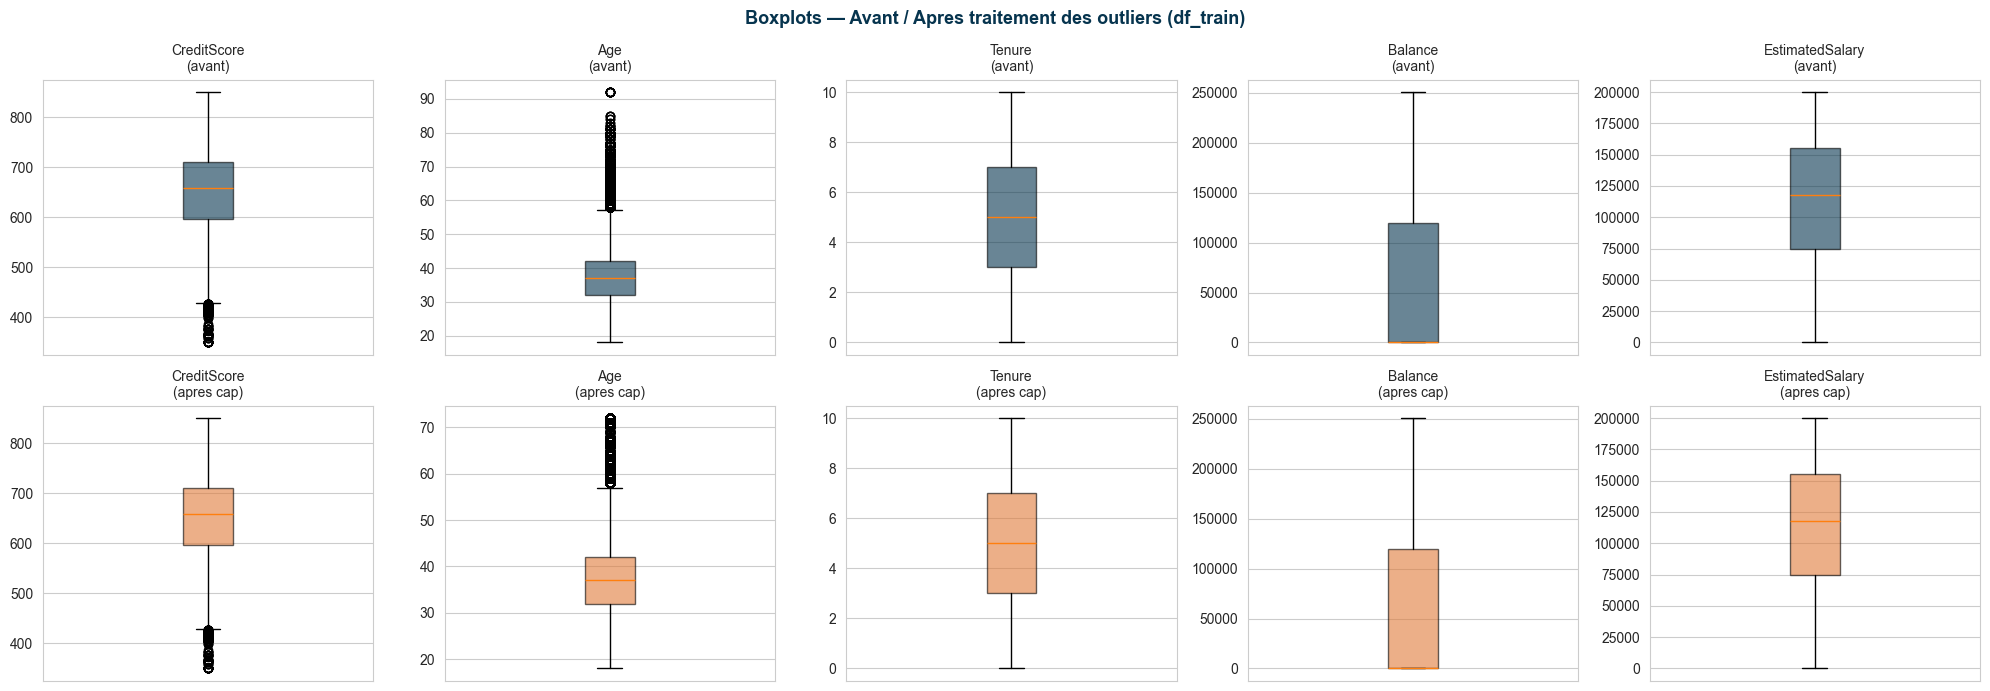

In [7]:
cols_plot = [c for c in columns_oc if c in df_train.columns and c in df_train_before.columns]
n = len(cols_plot)
if n > 0:
    fig, axes = plt.subplots(2, n, figsize=(4 * n, 7))
    if n == 1:
        axes = axes.reshape(2, 1)
    for j, col in enumerate(cols_plot):
        for row_i, (src, lbl, color) in enumerate([
            (df_train_before[col].dropna(), "avant",     COULEUR_PRINCIPALE),
            (df_train[col].dropna(),        "apres cap", COULEUR_CHURN),
        ]):
            axes[row_i, j].boxplot(src, patch_artist=True,
                                   boxprops=dict(facecolor=color, alpha=0.6))
            axes[row_i, j].set_title(f"{col}\n({lbl})", fontsize=10)
            axes[row_i, j].set_xticks([])
    plt.suptitle("Boxplots — Avant / Apres traitement des outliers (df_train)",
                 fontsize=13, fontweight="bold", color=COULEUR_PRINCIPALE)
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / "outliers_boxplots.png", dpi=300, bbox_inches="tight")
    plt.show()


<a id="section-5"></a>
## Section 5 : Verification des contraintes metier

Les contraintes metier sont appliquees dans le pipeline de nettoyage : les lignes qui violent les bornes sont **supprimees** pour garantir la coherence du dataset.  
Cette section verifie qu'aucune violation ne subsiste apres le pipeline.

| Variable | Borne min | Borne max | Justification |
|---|:---:|:---:|---|
| `CreditScore` | 300 | 850 | Echelle FICO standard |
| `Age` | 18 | 120 | Norme bancaire internationale |
| `Tenure` | 0 | 50 | Fortuneo fondee en 2000 ; marge pour fusions historiques |
| `Balance` | 0 | — | Solde non negatif dans ce contexte |
| `NumOfProducts` | 1 | 10 | Catalogue Fortuneo : 8-10 produits |
| `HasCrCard` | 0 | 1 | Binaire |
| `IsActiveMember` | 0 | 1 | Binaire |


In [8]:
# Verification des contraintes metier apres pipeline de nettoyage
bounds_cfg = OmegaConf.to_container(
    cfg.cleaning.steps.business_constraints.bounds, resolve=True
)
all_ok = True
for split_name, split_df in [("Train", df_train), ("Test", df_test)]:
    for col, limits in bounds_cfg.items():
        if col not in split_df.columns:
            continue
        mask = pd.Series(True, index=split_df.index)
        if limits.get("min") is not None:
            mask &= split_df[col] >= limits["min"]
        if limits.get("max") is not None:
            mask &= split_df[col] <= limits["max"]
        n_violations = (~mask).sum()
        if n_violations > 0:
            print(f"  {split_name} — {col} : {n_violations} violation(s) residuelles")
            all_ok = False
if all_ok:
    print("Toutes les contraintes metier sont respectees dans df_train et df_test.")
logger.info("Contraintes metier post-pipeline : %s", 'OK' if all_ok else 'violations')


2026-05-09 10:30:20,997 - __main__ - INFO - Contraintes metier post-pipeline : OK


Toutes les contraintes metier sont respectees dans df_train et df_test.


# **Feature engineering**

<a id="section-6"></a>
## Section 6 : Variables de base et justification

Les données prétraitées alimentent un pipeline qui produit **15 variables** en deux groupes :
- **11 variables de base** : 8 numériques conservées + 3 encodées one-hot (Geography et Gender)
- **4 ratios construits** : normalisent les variables par leur contexte (Section 7)

### Groupe 1 : Variables numériques (8 variables)

Ces 8 variables sont conservées en continu depuis le dataset brut. Elles couvrent les dimensions financières, comportementales et démographiques les plus discriminantes.

**Age** : 
Le churn explose entre 40 et 60 ans : 38.8 % pour 40-50 ans, 60.9 % pour 50-60 ans, contre 8 % pour les moins de 30 ans. Variable continue : l'encodage en tranches ferait perdre la granularité que les modèles non-linéaires peuvent exploiter directement.

**CreditScore** : 
Il signal de solvabilité et de profil client. Faible corrélation directe avec Exited, mais utile pour les arbres et le gradient boosting qui peuvent capturer des effets de seuil non-linéaires.

**Balance** : 
Très discriminant : Balance > 0 correspond à 27.1 % de churn, Balance = 0 correspond à 16.2 %. Conservé en continu plutôt qu'en flag binaire pour que le modèle apprenne lui-même les seuils optimaux.

**EstimatedSalary** : 
Il capture le niveau de revenus du client. C'est un indicateur de sa valeur potentielle et de son pouvoir d'utilisation des produits financiers. Faible corrélation directe mais interaction utile avec Balance.

**NumOfProducts** :
Variable hautement discriminante : 1 produit correspond à 34.7 %, 2 produits correspond à 6.0 %, 3+ correspond à 88 %. Conservé comme entier pour que le modèle capture les effets de chaque palier (1, 2, 3+).

**IsActiveMember** :
L'un des meilleurs prédicteurs individuels : inactifs churent à 30 % contre 12.5 % pour les actifs (écart de 17.5 points). Binaire 0/1 directement exploitable.

**Tenure** :
Ancienneté dans la banque. Faible corrélation directe (≈ -0.02) mais variable utile en conjonction avec Age et Balance. Retenu pour la richesse de ses interactions.

**HasCrCard** :
Signal de multi-bancarisation. Effet faible seul (21 % vs 23 %), mais interagit avec IsActiveMember. Retenu pour ses effets de second ordre.

### Groupe 2 : Variable encodées (3 variables)

`Geography` (3 modalités) et `Gender` (2 modalités) sont encodés manuellement en indicateurs binaires. Les modalités de référence (France, Female) sont implicitement représentées par (0, 0), cela évite la multicolinéarité parfaite.

**Geography_Germany**
Formule : `(Geography == 'Germany').astype(int)`
L'Allemagne churne à **37.9 %** contre 16.5 % pour la France (référence) et 17.2 % pour l'Espagne. L'écart de +21 points justifie un indicateur binaire dédié qui permettra aux modèles d'apprendre un coefficient spécifique à ce marché.

**Geography_Spain**
Formule : `(Geography == 'Spain').astype(int)`
L'Espagne churne à 17.2 %, très proche de la France (16.5 %). Retenu pour la complétude de l'encodage : quand `Geography_Germany = 0` et `Geography_Spain = 0`, le modèle identifie automatiquement la France.

**Gender_Male**
Formule : `(Gender == 'Male').astype(int)`
Les femmes churent à **28.0 %** contre 16.0 % pour les hommes, un écart de 12 points significatif observé dans l'EDA. Female = 0 (référence), Male = 1. Directement exploitable sans transformation supplémentaire.

<a id="section-7"></a>
## Section 7 : Variables construites

Les 4 ratios suivants sont calculés automatiquement dans `src/feature_engineering/feature_engineering.py` via `_compute_ratios()`, après l'encodage et avant la sélection finale.

L'idée centrale est que **la même valeur absolue d'une variable n'a pas le même sens selon le contexte** (âge du client, nombre de produits). Les ratios capturent cette relativité que les modèles linéaires ne peuvent pas apprendre seuls.


`Balance_per_Product` = Balance / (NumOfProducts + 1)

**Formule** : Solde bancaire divisé par le nombre de produits détenus.

**Justification** : Un client avec 100 000 € sur 1 produit est fondamentalement différent d'un client avec 100 000 € sur 4 produits. Le premier concentre son patrimoine, relation forte avec la banque. Le second dilue sur plusieurs produits, signal possible d'insatisfaction ou de multi-bancarisation. Ce ratio révèle la **densité patrimoniale par produit**, que `Balance` et `NumOfProducts` séparément ne capturent pas.


`Tenure_Age_Ratio` = Tenure / (Age + 1)

**Formule** : Ancienneté dans la banque divisée par l'âge du client.

**Justification** : 10 ans d'ancienneté signifie très peu pour un client de 60 ans (16 % de sa vie adulte) mais est considérable pour un client de 28 ans (36 % de sa vie adulte). Ce ratio mesure la **fidélité relative à l'âge de vie**, distinguant les clients fidèles depuis leur jeunesse des clients qui ont rejoint la banque tardivement.


`Balance_Age_Ratio` = Balance / (Age + 1)

**Formule** : Solde bancaire divisé par l'âge du client.

**Justification** : Un senior de 55 ans avec 50 000 € est sous-capitalisé par rapport à son cycle de vie (retraite proche, besoin patrimonial élevé), risque de départ vers une banque offrant de meilleurs produits d'épargne. Un client de 30 ans avec 50 000 € est sur-capitalisé pour son âge, profil très stable. Ce ratio normalise le patrimoine par **l'étape de vie financière** du client.


`Salary_Age` = EstimatedSalary / (Age + 1)

**Formule** : Salaire estimé divisé par l'âge du client.

**Justification** : Un revenu de 60 000 € est approprié pour un jeune de 28 ans mais frustrant pour un cadre de 52 ans. Ce décalage entre revenu et âge peut créer une **insatisfaction de statut** qui pousse à chercher une banque plus adaptée à un profil CSP+ attendu. Ce ratio capture l'écart entre le revenu réel et le revenu attendu par l'âge.

<a id="section-8"></a>
# Section 8 : Application du pipeline

In [9]:
# Recharge les modules au cas ou le noyau aurait mis en cache une ancienne version
importlib.reload(_fe_mod)
importlib.reload(_bf_mod)
from feature_engineering.build_features import run_feature_engineering_pipeline

df_train_fe = run_feature_engineering_pipeline(df_train, cfg)
df_test_fe  = run_feature_engineering_pipeline(df_test,  cfg)

print(f"Shape train apres FE : {df_train_fe.shape}")
print(f"Shape test  apres FE : {df_test_fe.shape}")

missing = [f for f in cfg.feature_engineering.created_features if f not in df_train_fe.columns]
if missing:
    raise RuntimeError(f"Features manquantes (train) : {missing}")
print(f"{len(cfg.feature_engineering.created_features)} features construites presentes")

# Sauvegarde des datasets pre-traites (utilises par les notebooks 03a et 03b)
PROCESSED_DIR = (PROJECT_ROOT / cfg.data.processed.dir).resolve()
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
df_train_fe.to_csv(PROCESSED_DIR / "train_processed.csv", index=False)
df_test_fe.to_csv(PROCESSED_DIR  / "test_processed.csv",  index=False)
print(f"Sauvegarde : train_processed.csv {df_train_fe.shape}, test_processed.csv {df_test_fe.shape}")

df_train_fe.head()


2026-05-09 10:30:21,032 - feature_engineering.build_features - INFO - --- Démarrage : Feature Engineering ---
2026-05-09 10:30:23,011 - feature_engineering.feature_engineering - INFO - Features sauvegardées dans C:\Users\DELL\Desktop\ise2\Semestre2\Statistiques\Machine Learning 2\Projet_ML2\Projet_ML2_G8\data\processed\data_final.csv
2026-05-09 10:30:23,019 - feature_engineering.build_features - INFO - ✓ Feature Engineering terminé. Shape: (132027, 16)
2026-05-09 10:30:23,019 - feature_engineering.build_features - INFO - --- Démarrage : Feature Engineering ---
2026-05-09 10:30:23,483 - feature_engineering.feature_engineering - INFO - Features sauvegardées dans C:\Users\DELL\Desktop\ise2\Semestre2\Statistiques\Machine Learning 2\Projet_ML2\Projet_ML2_G8\data\processed\data_final.csv
2026-05-09 10:30:23,485 - feature_engineering.build_features - INFO - ✓ Feature Engineering terminé. Shape: (33007, 16)


Shape train apres FE : (132027, 16)
Shape test  apres FE : (33007, 16)
15 features construites presentes
Sauvegarde : train_processed.csv (132027, 16), test_processed.csv (33007, 16)


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male,Balance_per_Product,Tenure_Age_Ratio,Balance_Age_Ratio,Salary_Age,Exited
0,726,35.0,1,0.00,2,1,1,141466.85,0,0,0,0.000000,0.028571,0.000000,4041.909885,0
1,481,37.0,8,152303.66,2,1,0,175082.20,0,0,0,76151.791924,0.216216,4116.315024,4731.951223,0
2,583,35.0,5,0.00,1,0,0,102581.11,0,0,0,0.000000,0.142857,0.000000,2930.888773,0
3,644,32.0,7,0.00,2,1,0,77965.67,0,0,0,0.000000,0.218750,0.000000,2436.427111,0
4,709,29.0,5,128548.49,1,1,1,140941.47,0,0,1,128548.361452,0.172414,4432.706399,4860.050522,0


In [10]:
colonnes_initiales = set(df_raw.columns)
colonnes_finales   = set(df_train_fe.columns)
new_columns        = sorted(colonnes_finales - colonnes_initiales)
dropped_columns    = sorted(colonnes_initiales - colonnes_finales)

print("Nouvelles colonnes   :", new_columns)
print("Colonnes supprimees  :", dropped_columns)


Nouvelles colonnes   : ['Balance_Age_Ratio', 'Balance_per_Product', 'Gender_Male', 'Geography_Germany', 'Geography_Spain', 'Salary_Age', 'Tenure_Age_Ratio']
Colonnes supprimees  : ['CustomerId', 'Gender', 'Geography', 'Surname', 'id']


<a id="section-9"></a>
# Section 9 : Contrôle des nouvelles variables

In [11]:
# Garde : relance le pipeline si df_train_fe est absent ou incomplet
if "df_train_fe" not in dir() or not all(
    f in df_train_fe.columns for f in cfg.feature_engineering.created_features
):
    print("df_train_fe incomplet — relance du pipeline...")
    df_train_fe = run_feature_engineering_pipeline(df_train, cfg)
    df_test_fe  = run_feature_engineering_pipeline(df_test,  cfg)

df_train_fe[cfg.feature_engineering.created_features].head()


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male,Balance_per_Product,Tenure_Age_Ratio,Balance_Age_Ratio,Salary_Age
0,726,35.0,1,0.00,2,1,1,141466.85,0,0,0,0.000000,0.028571,0.000000,4041.909885
1,481,37.0,8,152303.66,2,1,0,175082.20,0,0,0,76151.791924,0.216216,4116.315024,4731.951223
2,583,35.0,5,0.00,1,0,0,102581.11,0,0,0,0.000000,0.142857,0.000000,2930.888773
3,644,32.0,7,0.00,2,1,0,77965.67,0,0,0,0.000000,0.218750,0.000000,2436.427111
4,709,29.0,5,128548.49,1,1,1,140941.47,0,0,1,128548.361452,0.172414,4432.706399,4860.050522


In [12]:
quant_cols = [
    c for c in cfg.feature_engineering.created_features
    if c in df_train_fe.columns and df_train_fe[c].nunique() > 2
]
df_train_fe[quant_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
CreditScore,132027.0,656.497898,80.072181,350.000000,597.000000,659.000000,710.000000,850.000000
Age,132027.0,38.110985,8.822213,18.000000,32.000000,37.000000,42.000000,72.000000
Tenure,132027.0,5.017072,2.804446,0.000000,3.000000,5.000000,7.000000,10.000000
Balance,132027.0,55457.889422,62791.158845,0.000000,0.000000,0.000000,119859.555000,250898.090000
NumOfProducts,132027.0,1.553773,0.547302,1.000000,1.000000,2.000000,2.000000,4.000000
EstimatedSalary,132027.0,112485.647550,50308.143749,11.580000,74588.410000,117633.960000,155071.560000,199992.480000
Balance_per_Product,132027.0,46877.455294,56728.987947,0.000000,0.000000,0.000000,102944.907055,238387.321613
Tenure_Age_Ratio,132027.0,0.138537,0.085075,0.000000,0.068182,0.131579,0.200000,0.555556
Balance_Age_Ratio,132027.0,1508.219504,1787.187489,0.000000,0.000000,0.000000,3082.050341,10327.307204
Salary_Age,132027.0,3103.887946,1582.667307,0.222692,1932.820585,3043.890948,4192.485067,11077.246607


In [13]:
pd.DataFrame({
    "dtype"   : df_train_fe[cfg.feature_engineering.created_features].dtypes.astype(str),
    "n_unique": df_train_fe[cfg.feature_engineering.created_features].nunique(dropna=False),
})


,dtype,n_unique
CreditScore,int64,457
Age,float64,55
Tenure,int64,11
Balance,float64,25566
NumOfProducts,int64,4
HasCrCard,Int64,2
IsActiveMember,Int64,2
EstimatedSalary,float64,47181
Geography_Germany,int64,2
Geography_Spain,int64,2


<a id="section-10"></a>
# Section 10 : Synthèse

Le prétraitement et le feature engineering suivent un principe de **nettoyage rigoureux puis d'enrichissement justifié** :

**Partie 1 — Prétraitement :**
- Suppression des colonnes identifiantes (`id`, `CustomerId`, `Surname`)
- Winsorisation IQR (facteur 3) sur les variables continues
- Vérification et correction des contraintes métier (FICO, âge bancaire, solde positif)

**Partie 2 — Feature Engineering :**
- Encodage one-hot de Geography (France = référence) et Gender (Female = référence)
- Construction de 4 ratios métier capturant les effets de contexte (âge, nb produits)
- Sélection automatique des 15 features finales via `_select_final_columns`

Les **15 variables finales** couvrent trois groupes :

| Groupe | Variables | Traitement |
|---|---|---|
| **Numériques (8)** | `Age`, `CreditScore`, `Balance`, `EstimatedSalary`, `NumOfProducts`, `IsActiveMember`, `Tenure`, `HasCrCard` | Conservées telles quelles |
| **Encodées (3)** | `Geography_Germany`, `Geography_Spain`, `Gender_Male` | One-hot (France, Female = référence 0) |
| **Ratios construits (4)** | `Balance_per_Product`, `Tenure_Age_Ratio`, `Balance_Age_Ratio`, `Salary_Age` | Division avec +1 pour éviter la division par zéro |

**Variables non retenues** : `id`, `CustomerId`, `Surname` (identifiants sans valeur prédictive), `Geography` et `Gender` bruts (remplacés par leurs encodages binaires).

## **A suivre**

03a_notebook_modelisation et 03b_notebook_modelisation